<a href="https://colab.research.google.com/github/mteresadeb/survey-qc-automation/blob/main/notebook/survey_qc_walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Survey QC Automation — Walkthrough

This notebook demonstrates an automated quality control (QC) pipeline for survey field data.

The routines detect common problems that occur during large-scale F2F and CATI surveys, replacing manual verification processes that typically take one to two days per study.

---

## Checks covered

| # | Check | What it detects |
|---|---|---|
| 1 | Household members | Mismatch between selection grid and questionnaire |
| 2 | Age | Discrepancy > 2 years between selection grid and questionnaire |
| 3 | Gender | Mismatch between selection grid and questionnaire |
| 4 | Education | Inconsistency between years of study and declared level |
| 5 | Minor authorization | Underage respondent interviewed without consent |
| 6 | Income | Values outside expected range |
| 7 | Duration (short) | Interviews completed below minimum threshold |
| 8 | Duration (long) | Interviews over 1h10 |
| 9 | System flags | Issues flagged by the data collection platform |
| 10 | Partial racing | High % of answers given in under 3 seconds |
| 11 | Members under 15 | Unusually high count of household members under 15 |
| 12 | Food spending vs income | Spending exceeds or is inconsistent with income |
| 13 | NEC visits | 3+ 'nobody home' visits to the same household on the same day |
| 14 | Visit intervals | Two consecutive attempts less than 2h apart |
| 15 | First-attempt rate | PSU with over 50% completed on first attempt |
| 16 | Daily interview count | Interviewer with 10+ completed interviews in one day |
| 17 | Audio authorization | PSU with less than 50% audio consent |
| 18 | Nighttime interviews | Interviews completed between 21h and 6h |

**Note:** All data used here is synthetic. No real respondents or field data are included.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time as dtime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)

CODIGOS_AGENDAMENTO = {2, 4, 6}

codigo_visita_desc = {
    1: 'Completed interview',     2: 'Interrupted interview',
    3: 'Refusal',                 4: 'NEC (nobody home)',
    5: 'Absent for field period', 6: 'Temporarily absent',
    7: 'Access denied',           8: 'Sick/hospitalized',
    9: 'Language barrier',       10: 'No eligible resident',
   11: 'Other reason',
}

niveis_escol = {
    0: 'no schooling',
    1: 'incomplete primary (up to 5y)',
    2: 'complete primary / incomplete lower secondary (4-9y)',
    3: 'complete lower secondary / incomplete upper secondary (8-12y)',
    4: 'complete upper secondary (10-13y)',
    5: 'incomplete higher education (up to 15y)',
    6: 'complete higher education (16y+)',
}

print('Setup complete.')

Setup complete.


## 2. Synthetic dataset

We generate a dataset that mirrors the structure of a real survey export.
Known problems are injected into specific rows so each check has something to detect.

In [ ]:
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'SbjNum':                range(1001, 1001 + n),
    'DeviceIndex':           [f'DEV{i:04d}' for i in range(1, n + 1)],
    'Status':                np.random.choice(['Completed','Completed','Completed','Canceled'], n),
    'Srvyr':                 np.random.choice([101, 102, 103, 104, 105], n),
    'Srvyr_original':        [f'Interviewer_{np.random.choice([101,102,103,104,105])}' for _ in range(n)],
    'Fornecedor':            'Supplier A',
    'PSU_tratada':           [f'PSU{np.random.randint(1,21):02d}' for _ in range(n)],
    'Audio_Gravado':         np.random.choice(['Sim', 'Nao'], n, p=[0.7, 0.3]),
    'Autorizou_Recontato':   np.random.choice(['Sim', 'Nao'], n),
    'Duracao':               np.random.normal(25, 6, n).round(1),
    'VEnd_datetime':         pd.date_range('2024-03-01 08:00', periods=n, freq='45min'),
    'Kish_age':              np.random.randint(18, 75, n),
    'Ent_age':               np.random.randint(18, 75, n),
    'Kish_gender':           np.random.choice([1, 2], n),
    'Ent_Gender':            np.random.choice([1, 2], n),
    'Kish_membros':          np.random.randint(1, 7, n),
    'Ent_membros':           np.random.randint(1, 7, n),
    'Membros_menos15anos':   np.random.randint(0, 4, n),
    'Years_educ':            np.random.randint(0, 20, n),
    'Level_educ':            np.random.choice([0,1,2,3,4,5,6], n),
    'Autor_menor':           np.random.choice([1, 2], n),
    'Renda_num':             np.random.choice([1500,2500,3500,5000,np.nan], n),
    'Gasto_alim_num':        np.random.uniform(300, 2000, n).round(2),
    'Renda_efetiva':         np.random.choice([1500,2500,3500,5000,np.nan], n),
    'Porcentagem_menos3s':   np.random.uniform(0, 30, n).round(1),
    'Tentativas_por_completa': np.random.choice([1,1,2,3], n),
    'FlagsText':             None,
    'Flagsbyscript':         False,
})

for i in range(1, 7):
    df[f'I_{i}_VisitDate'] = '2024-03-01'
    df[f'I_{i}_VisitTime'] = f'{8 + i*2:02d}:00:00'
    df[f'I_{i}_Code']      = np.random.choice([1, 3, 4, 6], n)

df.loc[0,  ['Kish_membros', 'Ent_membros']]             = [4, 2]
df.loc[1,  ['Kish_age', 'Ent_age']]                     = [45, 28]
df.loc[2,  ['Kish_gender', 'Ent_Gender']]               = [1, 2]
df.loc[3,  ['Years_educ', 'Level_educ']]                = [3, 4]
df.loc[4,  ['Kish_age', 'Autor_menor']]                 = [16, 2]
df.loc[5,  ['Renda_num', 'Renda_efetiva']]              = [200.0, 200.0]
df.loc[6,  'Duracao']                                   = 5.0
df.loc[7,  'Duracao']                                   = 85.0
df.loc[8,  ['FlagsText', 'Flagsbyscript']]              = ['Duration is shorter than 600 seconds', True]
df.loc[9,  'Porcentagem_menos3s']                       = 35.0
df.loc[10, 'Membros_menos15anos']                       = 8
df.loc[11, ['Renda_efetiva', 'Gasto_alim_num']]         = [800.0, 1400.0]
for i in [1,2,3]:
    df.loc[12, f'I_{i}_Code'] = 4
    df.loc[12, f'I_{i}_VisitDate'] = '2024-03-01'
df.loc[13, ['I_1_VisitTime','I_1_Code','I_2_VisitTime','I_2_Code']] = ['09:00:00',3,'09:40:00',3]
for i in range(10):
    df.loc[20+i, ['PSU_tratada','Status','Tentativas_por_completa']] = ['PSU99','Completed',1]
for i in range(10):
    df.loc[30+i, ['Srvyr_original','VEnd_datetime','Status']] = ['Interviewer_999', pd.Timestamp('2024-03-05 14:00'), 'Completed']
for i in range(10):
    df.loc[50+i, ['PSU_tratada','Status','Audio_Gravado']] = ['PSU88','Completed','Nao' if i < 8 else 'Sim']
df.loc[60, ['VEnd_datetime','Status']] = [pd.Timestamp('2024-03-02 22:30'), 'Completed']

Base = df.query("Status not in ['Canceled','Expired']").reset_index(drop=True)
print(f'Active interviews: {len(Base)}')
Base[['SbjNum','Srvyr','Status','Duracao','Kish_age','Ent_age']].head()

Active interviews: 155


,SbjNum,Srvyr,Status,Duracao,Kish_age,Ent_age
0,1001,101,Completed,25.6,47,29
1,1003,105,Completed,28.0,48,63
2,1004,104,Completed,18.7,35,49
3,1005,105,Completed,22.9,16,32
4,1007,103,Completed,5.0,31,71


## 3. Helper functions

In [ ]:
def _parse_date_safe(v):
    if pd.isna(v): return None
    s = str(v).strip()
    if s in ('','nan','none'): return None
    dt = pd.to_datetime(s, errors='coerce', dayfirst=True)
    return None if pd.isna(dt) else dt.date()

def _parse_int_safe(v):
    if pd.isna(v): return None
    try: return int(float(str(v).strip().replace(',','.')))
    except: return None

def _parse_datetime_visit(row, i):
    d = _parse_date_safe(row.get(f'I_{i}_VisitDate'))
    if d is None: return None
    t_raw = row.get(f'I_{i}_VisitTime')
    if pd.isna(t_raw): return None
    t_str = str(t_raw).strip()
    if t_str in ('','nan','none'): return None
    try:
        parts = t_str.split(':')
        h, m = int(parts[0]), int(parts[1])
        s = int(parts[2]) if len(parts) > 2 else 0
        return datetime.combine(d, dtime(h, m, s))
    except: return None

def check_escolaridade(row):
    if row['Years_educ'] < 98:
        if (row['Level_educ'] == 0 and row['Years_educ'] != 0) or \
           (row['Level_educ'] == 1 and not (0 <= row['Years_educ'] <= 5)) or \
           (row['Level_educ'] == 2 and not (4 <= row['Years_educ'] <= 9)) or \
           (row['Level_educ'] == 3 and not (8 <= row['Years_educ'] <= 12)) or \
           (row['Level_educ'] == 4 and not (10 <= row['Years_educ'] <= 13)) or \
           (row['Level_educ'] == 5 and not (12 <= row['Years_educ'] <= 15)) or \
           (row['Level_educ'] == 6 and row['Years_educ'] < 15):
            return True
    return False

def check_membros(row):
    kish, ent = row.get('Kish_membros'), row.get('Ent_membros')
    if pd.isna(kish) or pd.isna(ent): return False
    try: return int(float(str(kish))) != int(float(str(ent)))
    except: return kish != ent

def get_nec_3plus_same_day_info(row, max_visits=6):
    nec_counts = {}
    for dom in range(max_visits // 3):
        i_start = dom * 3 + 1
        for i in range(i_start, i_start + 3):
            d = _parse_date_safe(row.get(f'I_{i}_VisitDate'))
            if d is None: continue
            if _parse_int_safe(row.get(f'I_{i}_Code')) == 4:
                key = (dom, d)
                nec_counts[key] = nec_counts.get(key, 0) + 1
    for (_, d), cnt in nec_counts.items():
        if cnt >= 3:
            return (True, d.strftime('%d/%m/%Y'), cnt)
    return (False, None, 0)

def get_intervalo_tentativas_info(row, max_visits=6):
    for dom in range(max_visits // 3):
        i_start = dom * 3 + 1
        visitas = []
        for i in range(i_start, i_start + 3):
            dt   = _parse_datetime_visit(row, i)
            code = _parse_int_safe(row.get(f'I_{i}_Code'))
            if dt and code:
                visitas.append((i, dt, code))
        visitas.sort(key=lambda x: x[1])
        for k in range(len(visitas) - 1):
            ia, dta, ca = visitas[k]
            ib, dtb, cb = visitas[k+1]
            if ca in CODIGOS_AGENDAMENTO or cb in CODIGOS_AGENDAMENTO: continue
            diff = (dtb - dta).total_seconds() / 60
            if diff < 120:
                return (True, ia, ib, diff, ca, cb)
    return (False, None, None, None, None, None)

def check_horario_noturno(vend_datetime):
    if pd.isna(vend_datetime): return False
    h = pd.Timestamp(vend_datetime).hour
    return h >= 21 or h < 6

def build_df(lista, desc_func):
    frames = []
    for i in lista:
        linha = Base.iloc[[i]].copy()
        linha['Problem'] = desc_func(Base.iloc[i])
        frames.append(linha)
    return pd.concat(frames) if frames else pd.DataFrame()

def build_df_info(lista, info_dict, desc_func):
    frames = []
    for idx in lista:
        linha = Base.iloc[[idx]].copy()
        linha['Problem'] = desc_func(*info_dict[idx])
        frames.append(linha)
    return pd.concat(frames) if frames else pd.DataFrame()

print('Helper functions ready.')

Helper functions ready.


## 4. Running QC checks

In [ ]:
# Checks 1-4: demographic consistency
membros_lista      = Base.index[Base.apply(check_membros, axis=1)].tolist()
idade_lista        = Base.index[abs(Base['Kish_age'] - Base['Ent_age']) > 2].tolist()
sexo_lista         = Base.index[Base['Kish_gender'] != Base['Ent_Gender']].tolist()
escolaridade_lista = Base.index[Base.apply(check_escolaridade, axis=1)].tolist()

# Check 5: minor without authorization
menor_lista = Base.index[(Base['Kish_age'] < 18) & (Base['Autor_menor'] != 1)].tolist()

# Check 6: income out of range
renda_lista = Base.index[
    Base['Renda_num'].notna() &
    ((Base['Renda_num'] < 500) | (Base['Renda_num'] > 50000))
].tolist()

# Checks 7-8: duration
duracao_lista       = Base.index[Base['Duracao'] < 19].tolist()
duracao_longa_lista = Base.index[Base['Duracao'] > 70].tolist()

# Check 9: system flags
flags_lista = Base.index[Base['Flagsbyscript'] == True].tolist()

# Check 10: partial racing
parcial_lista = Base.index[Base['Porcentagem_menos3s'] >= 20].tolist()

# Check 11: members under 15
membros15_lista = Base.index[Base['Membros_menos15anos'] > 6].tolist()

# Check 12: food spending vs income
gasto_lista = Base.index[
    (Base['Gasto_alim_num'].notna() & Base['Renda_efetiva'].notna() &
     (Base['Gasto_alim_num'] > Base['Renda_efetiva'])) |
    (Base['Gasto_alim_num'].notna() & Base['Renda_efetiva'].notna() &
     (Base['Gasto_alim_num'] == 0) & (Base['Renda_efetiva'] > 0)) |
    (Base['Gasto_alim_num'].notna() & (Base['Gasto_alim_num'] > 0) &
     Base['Renda_efetiva'].isna())
].tolist()

# Check 13: NEC visits
nec_lista, nec_info = [], {}
for idx, row in Base.iterrows():
    flag, data_v, qtd = get_nec_3plus_same_day_info(row)
    if flag:
        nec_lista.append(idx)
        nec_info[idx] = (data_v, qtd)

# Check 14: visit intervals
intervalo_lista, intervalo_info = [], {}
for idx, row in Base.iterrows():
    flag, ia, ib, mins, ca, cb = get_intervalo_tentativas_info(row)
    if flag:
        intervalo_lista.append(idx)
        intervalo_info[idx] = (ia, ib, mins, ca, cb)

# Check 15: first-attempt rate by PSU
alta_psu_lista, alta_psu_info = [], {}
completed = Base.query("Status == 'Completed'").copy()
if not completed.empty:
    total_psu = completed.groupby('PSU_tratada').size().rename('Total')
    first_psu = completed.query("Tentativas_por_completa == 1").groupby('PSU_tratada').size().rename('First')
    stats = pd.merge(total_psu, first_psu, left_index=True, right_index=True, how='left').fillna(0)
    stats['Pct'] = (stats['First'] / stats['Total'] * 100).round(1)
    for psu, row in stats[(stats['Total'] >= 10) & (stats['Pct'] > 50)].iterrows():
        for idx in Base.index[Base['PSU_tratada'] == psu]:
            if idx not in alta_psu_lista:
                alta_psu_lista.append(idx)
                alta_psu_info[idx] = (psu, row['Pct'])

# Check 16: 10+ interviews per day per interviewer
dia_lista, dia_info = [], {}
tmp = Base.copy()
tmp['VEnd_date'] = pd.to_datetime(tmp['VEnd_datetime'], errors='coerce').dt.date
tmp = tmp.dropna(subset=['VEnd_date', 'Srvyr_original'])
if not tmp.empty:
    contagem = tmp.groupby(['Srvyr_original','VEnd_date']).size().reset_index(name='Count')
    for _, r in contagem[contagem['Count'] >= 10].iterrows():
        mask = (
            (pd.to_datetime(Base['VEnd_datetime'], errors='coerce').dt.date == r['VEnd_date']) &
            (Base['Srvyr_original'] == r['Srvyr_original'])
        )
        for idx in Base.index[mask]:
            if idx not in dia_lista:
                dia_lista.append(idx)
                dia_info[idx] = (r['Srvyr_original'], r['VEnd_date'].strftime('%d/%m/%Y'), r['Count'])

# Check 17: low audio authorization by PSU
audio_lista, audio_info = [], {}
comp_psu = Base.query("Status == 'Completed'").copy()
if not comp_psu.empty:
    for psu, group in comp_psu.groupby('PSU_tratada'):
        if len(group) >= 10:
            pct = group.query("Audio_Gravado == 'Sim'").shape[0] / len(group) * 100
            if pct < 50:
                for idx in group.index:
                    if idx not in audio_lista:
                        audio_lista.append(idx)
                        audio_info[idx] = (psu, pct)

# Check 18: nighttime interviews
noturno_lista, noturno_info = [], {}
for idx, row in Base.query("Status == 'Completed'").iterrows():
    if check_horario_noturno(row['VEnd_datetime']):
        noturno_lista.append(idx)
        noturno_info[idx] = row['VEnd_datetime']

print('All 18 QC checks completed.')

All 18 QC checks completed.


## 5. Results summary

In [ ]:
checks = [
    ('Household members mismatch',     membros_lista),
    ('Age discrepancy',                idade_lista),
    ('Gender mismatch',                sexo_lista),
    ('Education inconsistency',        escolaridade_lista),
    ('Minor without authorization',    menor_lista),
    ('Income out of range',            renda_lista),
    ('Duration too short',             duracao_lista),
    ('Duration too long',              duracao_longa_lista),
    ('System flags',                   flags_lista),
    ('Partial racing',                 parcial_lista),
    ('Members under 15 (high count)',  membros15_lista),
    ('Food spending vs income',        gasto_lista),
    ('3+ NEC visits same day',         nec_lista),
    ('Visit interval < 2h',            intervalo_lista),
    ('High first-attempt rate (PSU)',  alta_psu_lista),
    ('10+ interviews same day',        dia_lista),
    ('Low audio authorization (PSU)',  audio_lista),
    ('Nighttime interview',            noturno_lista),
]

total = sum(len(lst) for _, lst in checks)
summary = pd.DataFrame([{'Check': n, 'Flagged': len(l)} for n, l in checks])
summary['% of interviews'] = (summary['Flagged'] / len(Base) * 100).round(1)

print(f'Interviews analyzed : {len(Base)}')
print(f'Total flags raised  : {total}\n')
summary

Interviews analyzed : 155
Total flags raised  : 718



,Check,Flagged,% of interviews
0,Household members mismatch,127,81.9
1,Age discrepancy,144,92.9
2,Gender mismatch,74,47.7
3,Education inconsistency,130,83.9
4,Minor without authorization,1,0.6
5,Income out of range,0,0.0
6,Duration too short,34,21.9
7,Duration too long,1,0.6
8,System flags,1,0.6
9,Partial racing,50,32.3


## 6. Visualizations

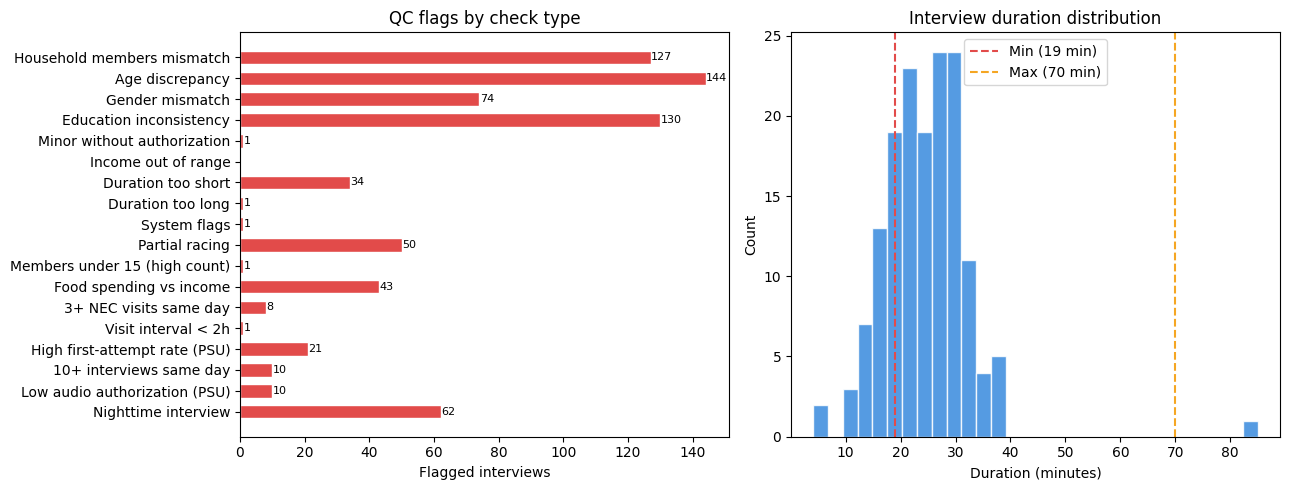

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = ['#E24B4A' if v > 0 else '#D3D1C7' for v in summary['Flagged']]
bars = ax.barh(summary['Check'], summary['Flagged'], color=colors, edgecolor='white', height=0.65)
ax.set_xlabel('Flagged interviews')
ax.set_title('QC flags by check type', fontsize=12)
ax.invert_yaxis()
for bar, val in zip(bars, summary['Flagged']):
    if val > 0:
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

ax2 = axes[1]
ax2.hist(Base['Duracao'], bins=30, color='#378ADD', alpha=0.85, edgecolor='white')
ax2.axvline(19, color='#E24B4A', linewidth=1.5, linestyle='--', label='Min (19 min)')
ax2.axvline(70, color='#F5A623', linewidth=1.5, linestyle='--', label='Max (70 min)')
ax2.set_xlabel('Duration (minutes)')
ax2.set_ylabel('Count')
ax2.set_title('Interview duration distribution', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

## 7. QC report

Each flagged record is combined into a single DataFrame with a `Problem` column describing the issue.
This report is reviewed by the research team and sent back to the field for correction or cancellation.

In [ ]:
membros_df    = build_df(membros_lista,      lambda r: f"Member count mismatch: {r['Kish_membros']} (grid) vs {r['Ent_membros']} (questionnaire).")
idade_df      = build_df(idade_lista,        lambda r: f"Age discrepancy: {r['Kish_age']} (grid) vs {r['Ent_age']} (questionnaire).")
sexo_df       = build_df(sexo_lista,         lambda r: f"Gender mismatch: {r['Kish_gender']} (grid) vs {r['Ent_Gender']} (questionnaire).")
escol_df      = build_df(escolaridade_lista, lambda r: f"Education inconsistency: declared '{niveis_escol.get(r['Level_educ'], r['Level_educ'])}' but years of study = {r['Years_educ']}.")
menor_df      = build_df(menor_lista,        lambda r: f"Underage respondent ({r['Kish_age']}y) interviewed without authorization.")
renda_df      = build_df(renda_lista,        lambda r: f"Income out of range: R${round(r['Renda_num'],2)}.")
duracao_df    = build_df(duracao_lista,      lambda r: f"Interview too short: {round(r['Duracao'],1)} min.")
duracao_lg_df = build_df(duracao_longa_lista,lambda r: f"Interview too long: {round(r['Duracao'],1)} min.")
membros15_df  = build_df(membros15_lista,    lambda r: f"High count of members under 15: {r['Membros_menos15anos']}.")
parcial_df    = build_df(parcial_lista,      lambda r: f"Partial racing: {r['Porcentagem_menos3s']}% of questions answered in under 3 seconds.")
renda_ef = lambda r: f"R${round(r['Renda_efetiva'],2)}" if pd.notna(r['Renda_efetiva']) else 'N/A'
gasto_df      = build_df(gasto_lista,        lambda r: f"Food spending (R${round(r['Gasto_alim_num'],2)}) inconsistent with income ({renda_ef(r)}).")

flags_df = pd.DataFrame()
if flags_lista:
    flags_df = pd.concat([Base.iloc[[i]] for i in flags_lista]).copy()
    flags_df['Problem'] = flags_df['FlagsText']

nec_df      = build_df_info(nec_lista,       nec_info,       lambda d,q:        f"{q} NEC visits on {d} for the same household.")
interv_df   = build_df_info(intervalo_lista, intervalo_info, lambda ia,ib,m,ca,cb: f"Visits {ia} and {ib} were {round(m,1)} min apart (min: 120 min).")
alta_psu_df = build_df_info(alta_psu_lista,  alta_psu_info,  lambda psu,pct:    f"PSU '{psu}': {pct:.1f}% completed on first attempt (above 50%).")
dia_df      = build_df_info(dia_lista,       dia_info,       lambda s,d,c:      f"Interviewer '{s}' completed {c} interviews on {d}.")
audio_df    = build_df_info(audio_lista,     audio_info,     lambda psu,pct:    f"PSU '{psu}': only {pct:.1f}% audio consent (below 50%).")
noturno_df = pd.DataFrame()
if noturno_lista:
    frames = []
    for idx in noturno_lista:
        linha = Base.iloc[[idx]].copy()
        dt = noturno_info[idx]
        linha['Problem'] = f"Interview completed at nighttime: {pd.Timestamp(dt).strftime('%H:%M:%S')}."
        frames.append(linha)
    noturno_df = pd.concat(frames)

report = pd.concat([
    membros_df, idade_df, sexo_df, escol_df, menor_df, renda_df,
    duracao_df, duracao_lg_df, flags_df, membros15_df, parcial_df,
    gasto_df, nec_df, interv_df, alta_psu_df, dia_df, audio_df, noturno_df,
], ignore_index=True, sort=False)

cols = ['SbjNum','Srvyr','Srvyr_original','PSU_tratada','Status','Duracao','Problem']
report_view = report[[c for c in cols if c in report.columns]]

print(f'Total flagged records: {len(report_view)}')
report_view.head(20)

Total flagged records: 718


,SbjNum,Srvyr,Srvyr_original,PSU_tratada,Status,Duracao,Problem
0,1001,101,Interviewer_101,PSU04,Completed,25.6,Member count mismatch: 4 (grid) vs 2 (questionnaire).
1,1004,104,Interviewer_105,PSU13,Completed,18.7,Member count mismatch: 4 (grid) vs 5 (questionnaire).
2,1005,105,Interviewer_102,PSU10,Completed,22.9,Member count mismatch: 2 (grid) vs 1 (questionnaire).
3,1007,103,Interviewer_103,PSU14,Completed,5.0,Member count mismatch: 2 (grid) vs 6 (questionnaire).
4,1008,105,Interviewer_102,PSU05,Completed,85.0,Member count mismatch: 5 (grid) vs 6 (questionnaire).
5,1009,104,Interviewer_101,PSU03,Completed,26.4,Member count mismatch: 6 (grid) vs 3 (questionnaire).
6,1011,103,Interviewer_104,PSU11,Completed,34.9,Member count mismatch: 5 (grid) vs 1 (questionnaire).
7,1012,103,Interviewer_102,PSU18,Completed,19.0,Member count mismatch: 1 (grid) vs 4 (questionnaire).
8,1014,102,Interviewer_104,PSU12,Completed,19.4,Member count mismatch: 3 (grid) vs 1 (questionnaire).
9,1016,105,Interviewer_104,PSU10,Completed,35.6,Member count mismatch: 1 (grid) vs 4 (questionnaire).


## 8. Export

In [ ]:
output_path = 'qc_report_sample.xlsx'
report_view.to_excel(output_path, index=False)
print(f'Report saved to: {output_path}')
print(f'Records : {len(report_view)}')
print(f'Columns : {list(report_view.columns)}')

Report saved to: qc_report_sample.xlsx
Records : 718
Columns : ['SbjNum', 'Srvyr', 'Srvyr_original', 'PSU_tratada', 'Status', 'Duracao', 'Problem']
